In [5]:
import numpy as np
import pandas as pd
from densmix.generator import Generator
from densmix.models import Models
import matplotlib.pyplot as plt

# densmix

<!-- badges: start -->
<!-- badges: end -->

Here we show several examples for densmix library related to exponential - normal density separation.

## Generate data and fit mixtures

We start by generating many datasets with set parameters and then using the library to decompose it. In this case we choose $lambda$, $mu$ and $sigma$ in a way that densities are well separated.

In [6]:
np.random.seed(123)

n_sim = 200

exp_norm_param_list = [
    {
        "weight": np.random.uniform(0.1, 0.9),
        "lambda": np.random.uniform(0.5, 5),
        "mu": np.random.uniform(7, 25),
        "sigma": np.random.uniform(1, 2)
    }
    for _ in range(n_sim)
]

exp_norm_gen_datasets_list = [
    Generator(
        size=1000,
        parameters=parameters
    ).gen_exp_norm()
    for parameters in exp_norm_param_list
]

exp_norm_fits_list = [
    Models(data).fit_exp_norm()
    for data in exp_norm_gen_datasets_list
]

exp_norm_true_param_df = pd.DataFrame(
    exp_norm_param_list
)

exp_norm_fit_param_df = pd.DataFrame([
    fit["parameters"]
    for fit in exp_norm_fits_list
])

## Scatterplots

Next, we compare parameters by looking at scatterplots:

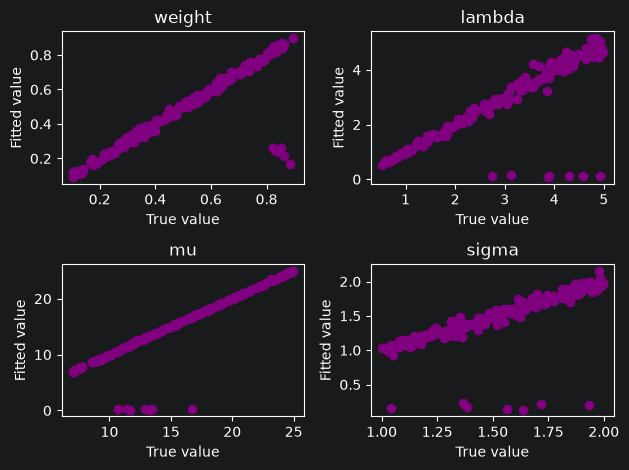

In [7]:
column_names = ["weight", "lambda", "mu", "sigma"]

fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

for ax, column_name in zip(axes, column_names):
    ax.scatter(
        exp_norm_true_param_df[column_name],
        exp_norm_fit_param_df[column_name],
        color="purple"
    )

    ax.set_xlabel("True value")
    ax.set_ylabel("Fitted value")
    ax.set_title(column_name)

plt.tight_layout()
plt.show()

We see that in most of the cases apart from 6 points, algorithm worked well and parameters are similar to one another.

Next, we check 6 suspicious points to discover that it happens when EM thinks that density close to zero is normal and provides a wrong fit:

In [10]:
unusual = exp_norm_fit_param_df[
    exp_norm_fit_param_df["mu"] < 1
]
unusual

,weight,lambda,mu,sigma
21,0.242316,0.103925,0.179179,0.153981
31,0.260311,0.115192,0.166971,0.140107
47,0.235282,0.137015,0.265810,0.222191
85,0.258257,0.121741,0.164818,0.136103
155,0.165656,0.079767,0.227650,0.198860
168,0.211641,0.118387,0.280759,0.232942
187,0.244485,0.129148,0.206888,0.171339


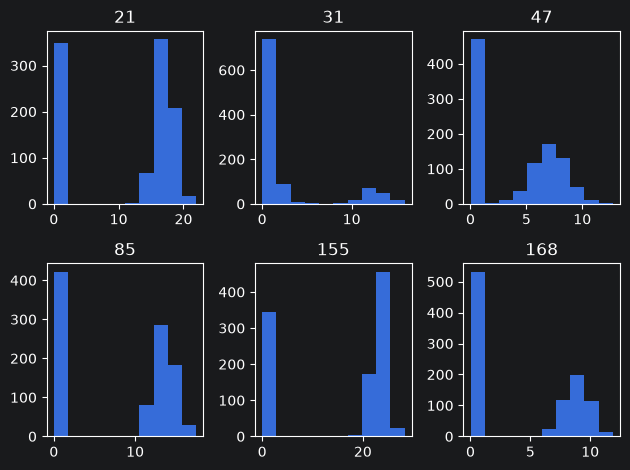

In [11]:
import matplotlib.pyplot as plt

dataset_numbers = unusual.index

fig, axes = plt.subplots(2, 3)
axes = axes.flatten()

for ax, dataset_number in zip(axes, dataset_numbers):
    ax.hist(
        exp_norm_gen_datasets_list[dataset_number - 1]
    )
    ax.set_title(str(dataset_number))

plt.tight_layout()
plt.show()

We also check how in many iterations algorithm converges:

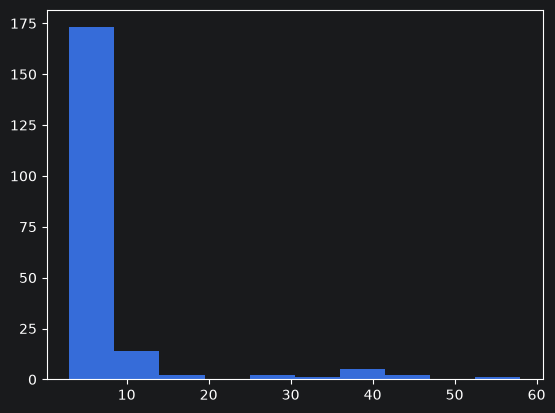

0.895


In [14]:
iteration_counts = np.array([
    fit["iterations"]
    for fit in exp_norm_fits_list
])

plt.hist(iteration_counts)
plt.show()

proportion_below_10 = np.mean(iteration_counts < 10)

print(proportion_below_10)

to see that it usually converges fast (around 90% of cases in under 10 iterations).